In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option('display.max_columns', None)

In [26]:
sentiment = pd.read_csv("fear_greed_index.csv")
trades = pd.read_csv("historical_data.csv")

print("Files loaded successfully!")

Files loaded successfully!


In [27]:
print("===== Fear & Greed Dataset =====")
display(sentiment.head())

print("\n===== Trader Dataset =====")
display(trades.head())

===== Fear & Greed Dataset =====


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05



===== Trader Dataset =====


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [28]:
print("===== Missing Values =====")
print("\nSentiment Dataset")
print(sentiment.isnull().sum())

print("\nTrader Dataset")
print(trades.isnull().sum())

print("\n==========================")

print("Duplicate rows in Sentiment:", sentiment.duplicated().sum())
print("Duplicate rows in Trader:", trades.duplicated().sum())

===== Missing Values =====

Sentiment Dataset
timestamp         0
value             0
classification    0
date              0
dtype: int64

Trader Dataset
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicate rows in Sentiment: 0
Duplicate rows in Trader: 0


In [29]:
# Convert sentiment date
sentiment["date"] = pd.to_datetime(sentiment["date"])

# Convert trader timestamp
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)

# Extract only the date
trades["date"] = trades["Timestamp IST"].dt.date
sentiment["date"] = sentiment["date"].dt.date

print("Dates converted successfully!")

Dates converted successfully!


In [30]:
merged = pd.merge(
    trades,
    sentiment[["date", "classification"]],
    on="date",
    how="left"
)

print("Merged Successfully!")
display(merged.head())

Merged Successfully!


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [31]:
daily_pnl = merged.groupby(["date", "classification"])["Closed PnL"].sum().reset_index()

display(daily_pnl.head())

,date,classification,Closed PnL
0,2023-05-01,Greed,0.000000
1,2023-12-05,Extreme Greed,0.000000
2,2023-12-14,Greed,-205.434737
3,2023-12-15,Greed,-24.632034
4,2023-12-16,Greed,0.000000


In [32]:
daily_trades = merged.groupby(["date", "classification"]).size().reset_index(name="Trade Count")

display(daily_trades.head())

,date,classification,Trade Count
0,2023-05-01,Greed,3
1,2023-12-05,Extreme Greed,9
2,2023-12-14,Greed,11
3,2023-12-15,Greed,2
4,2023-12-16,Greed,3


In [33]:
avg_trade_size = merged.groupby("classification")["Size USD"].mean().reset_index()

display(avg_trade_size)

,classification,Size USD
0,Extreme Fear,5349.731843
1,Extreme Greed,3112.251565
2,Fear,7816.109931
3,Greed,5736.884375
4,Neutral,4782.732661


In [34]:
avg_pnl = merged.groupby("classification")["Closed PnL"].mean().reset_index()

display(avg_pnl)

,classification,Closed PnL
0,Extreme Fear,34.537862
1,Extreme Greed,67.892861
2,Fear,54.290400
3,Greed,42.743559
4,Neutral,34.307718


In [35]:
merged["Win"] = merged["Closed PnL"] > 0

win_rate = merged.groupby("classification")["Win"].mean().reset_index()

win_rate["Win"] = win_rate["Win"] * 100

display(win_rate)

,classification,Win
0,Extreme Fear,37.060748
1,Extreme Greed,46.494299
2,Fear,42.076750
3,Greed,38.482794
4,Neutral,39.699093


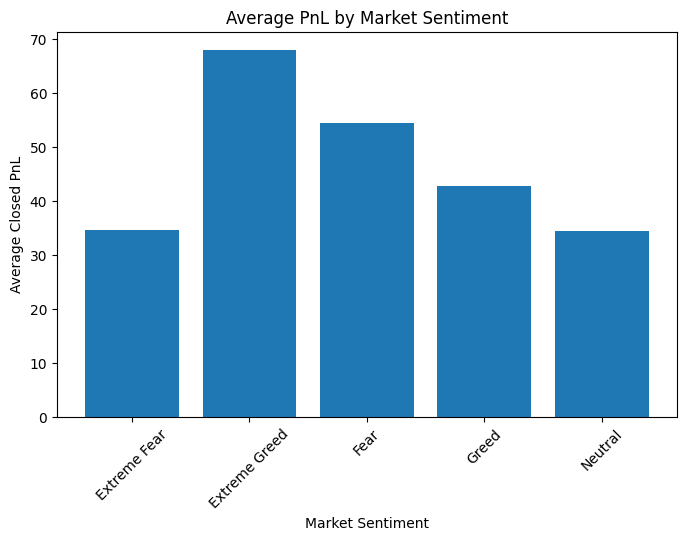

In [36]:
plt.figure(figsize=(8,5))

plt.bar(avg_pnl["classification"], avg_pnl["Closed PnL"])

plt.title("Average PnL by Market Sentiment")

plt.xlabel("Market Sentiment")

plt.ylabel("Average Closed PnL")

plt.xticks(rotation=45)

plt.show()

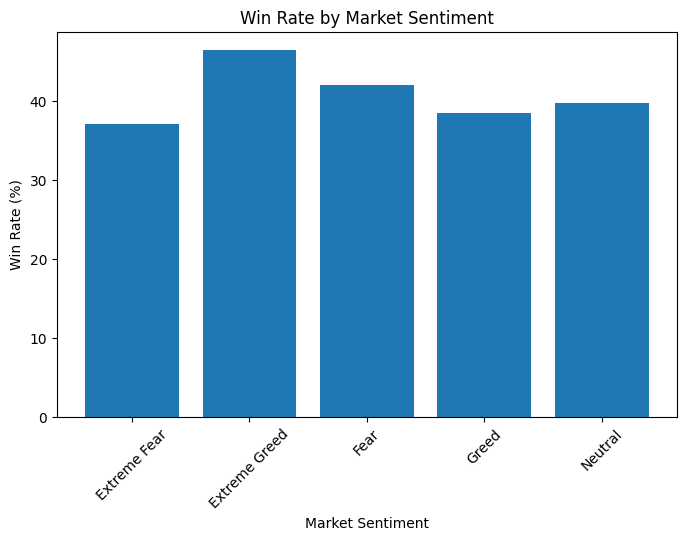

In [37]:
plt.figure(figsize=(8,5))

plt.bar(win_rate["classification"], win_rate["Win"])

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")

plt.xticks(rotation=45)

plt.show()

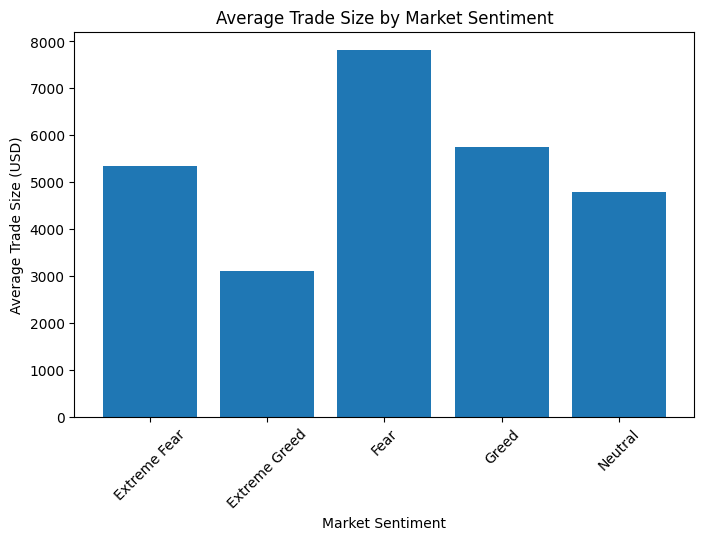

In [38]:
plt.figure(figsize=(8,5))

plt.bar(avg_trade_size["classification"], avg_trade_size["Size USD"])

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")

plt.xticks(rotation=45)

plt.show()

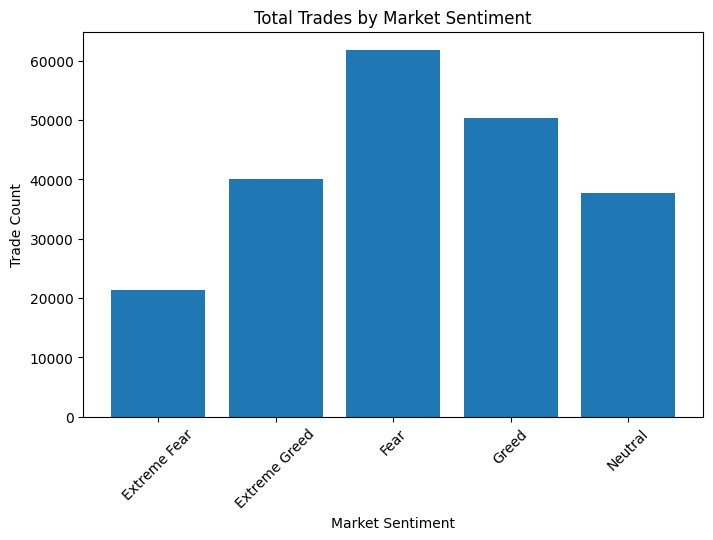

In [39]:
trade_summary = daily_trades.groupby("classification")["Trade Count"].sum().reset_index()

plt.figure(figsize=(8,5))

plt.bar(trade_summary["classification"], trade_summary["Trade Count"])

plt.title("Total Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Trade Count")

plt.xticks(rotation=45)

plt.show()

<Figure size 1000x600 with 0 Axes>

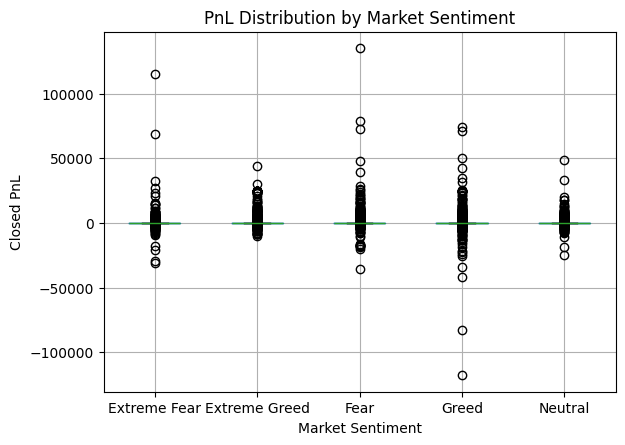

In [40]:
plt.figure(figsize=(10,6))

merged.boxplot(column="Closed PnL", by="classification")

plt.title("PnL Distribution by Market Sentiment")
plt.suptitle("")

plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")

plt.show()

,classification,Side,Trade Count
0,Extreme Fear,BUY,10935
1,Extreme Fear,SELL,10465
2,Extreme Greed,BUY,17940
3,Extreme Greed,SELL,22052
4,Fear,BUY,30270
5,Fear,SELL,31567
6,Greed,BUY,24576
7,Greed,SELL,25727
8,Neutral,BUY,18969
9,Neutral,SELL,18717


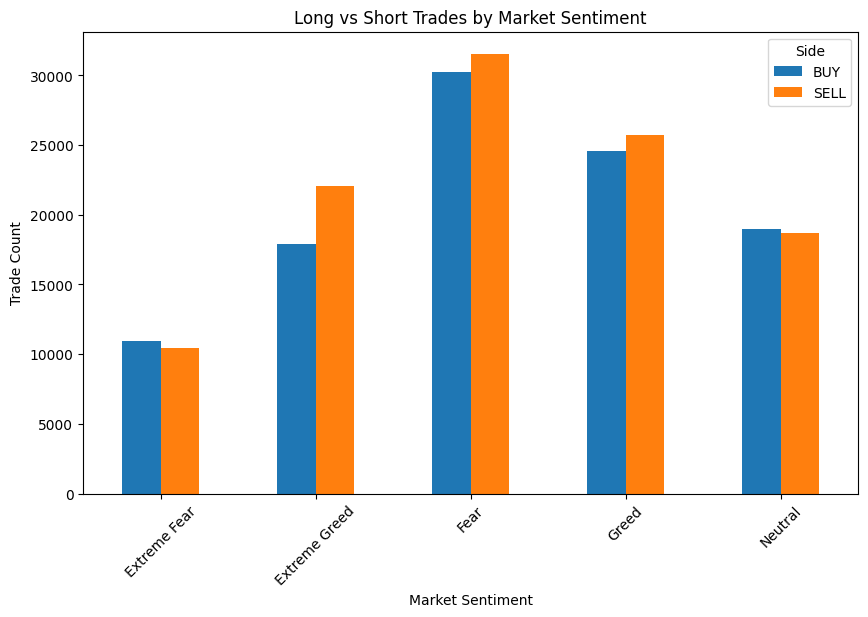

In [41]:
# Long vs Short Analysis

long_short = merged.groupby(["classification", "Side"]).size().reset_index(name="Trade Count")

display(long_short)

pivot_long_short = long_short.pivot(index="classification", columns="Side", values="Trade Count").fillna(0)

pivot_long_short.plot(kind="bar", figsize=(10,6))

plt.title("Long vs Short Trades by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Trade Count")
plt.xticks(rotation=45)

plt.show()

In [42]:
# Trader Activity

trader_activity = merged.groupby("Account").agg(
    Total_Trades=("Account", "count"),
    Total_PnL=("Closed PnL", "sum")
).reset_index()

# Frequent vs Infrequent Traders
median_trades = trader_activity["Total_Trades"].median()

trader_activity["Segment"] = np.where(
    trader_activity["Total_Trades"] >= median_trades,
    "Frequent",
    "Infrequent"
)

display(trader_activity.head())

,Account,Total_Trades,Total_PnL,Segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,1.600230e+06,Frequent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,7280,4.788532e+04,Frequent
2,0x271b280974205ca63b716753467d5a371de622ab,3809,-7.043619e+04,Frequent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311,1.324648e+05,Frequent
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3239,1.686580e+05,Infrequent


,Segment,Average_PnL,Average_Trades
0,Frequent,496527.661215,11684.8125
1,Infrequent,147032.272750,1516.6875


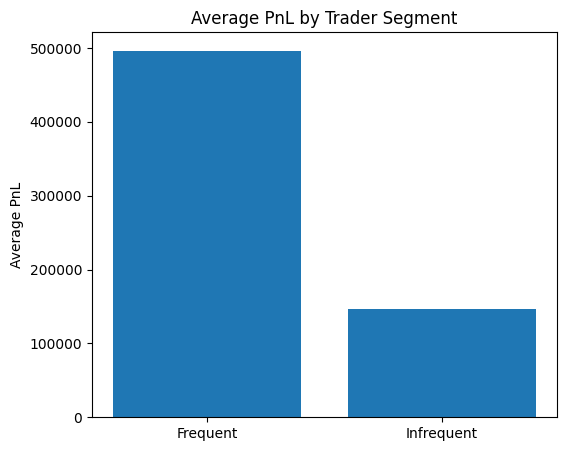

In [43]:
segment_summary = trader_activity.groupby("Segment").agg(
    Average_PnL=("Total_PnL","mean"),
    Average_Trades=("Total_Trades","mean")
).reset_index()

display(segment_summary)

plt.figure(figsize=(6,5))

plt.bar(segment_summary["Segment"], segment_summary["Average_PnL"])

plt.title("Average PnL by Trader Segment")
plt.ylabel("Average PnL")

plt.show()

,date,classification,Closed PnL
0,2023-05-01,Greed,0.000000
1,2023-12-05,Extreme Greed,0.000000
2,2023-12-14,Greed,-514.003130
3,2023-12-15,Greed,-15.479828
4,2023-12-16,Greed,0.000000


,classification,Closed PnL
0,Extreme Fear,-7999.779096
1,Extreme Greed,-455.228297
2,Fear,-1892.436526
3,Greed,-1509.674833
4,Neutral,-1381.746584


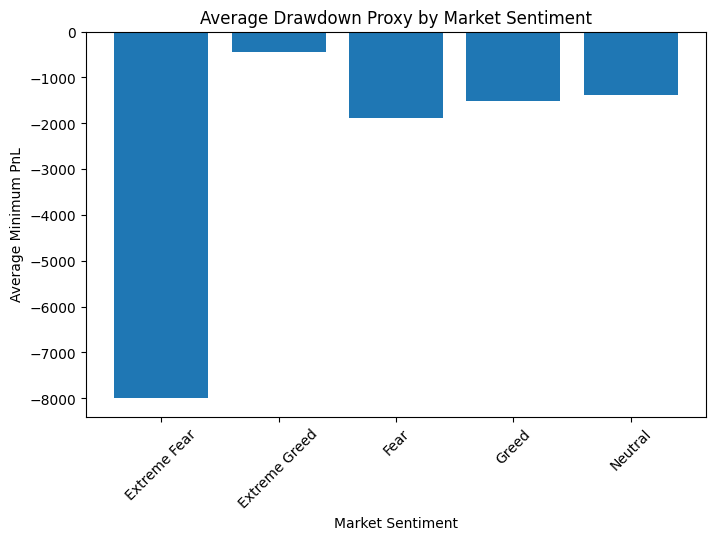

In [44]:
# Drawdown Proxy

drawdown = merged.groupby(["date", "classification"])["Closed PnL"].min().reset_index()

display(drawdown.head())

drawdown_avg = drawdown.groupby("classification")["Closed PnL"].mean().reset_index()

display(drawdown_avg)

plt.figure(figsize=(8,5))
plt.bar(drawdown_avg["classification"], drawdown_avg["Closed PnL"])

plt.title("Average Drawdown Proxy by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Minimum PnL")

plt.xticks(rotation=45)
plt.show()

In [45]:
# Trader Consistency

trader_stats = merged.groupby("Account").agg(
    Avg_PnL=("Closed PnL","mean"),
    Std_PnL=("Closed PnL","std"),
    Total_Trades=("Account","count")
).reset_index()

trader_stats["Std_PnL"] = trader_stats["Std_PnL"].fillna(0)

median_std = trader_stats["Std_PnL"].median()

trader_stats["Consistency"] = np.where(
    trader_stats["Std_PnL"] <= median_std,
    "Consistent Winner",
    "Inconsistent Winner"
)

display(trader_stats.head())

,Account,Avg_PnL,Std_PnL,Total_Trades,Consistency
0,0x083384f897ee0f19899168e3b1bec365f52a9012,419.127768,4692.452329,3818,Inconsistent Winner
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,6.577654,134.073473,7280,Consistent Winner
2,0x271b280974205ca63b716753467d5a371de622ab,-18.492043,542.182659,3809,Consistent Winner
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,9.951530,113.269353,13311,Consistent Winner
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,52.071011,255.829091,3239,Consistent Winner


,Consistency,Average_PnL,Traders
0,Consistent Winner,30.865072,16
1,Inconsistent Winner,164.507520,16


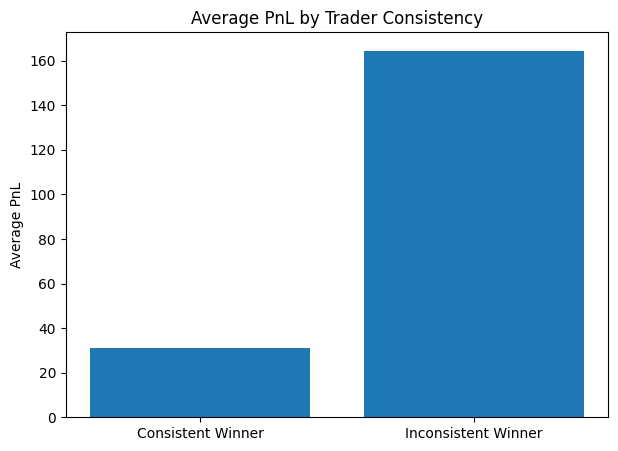

In [46]:
consistency_summary = trader_stats.groupby("Consistency").agg(
    Average_PnL=("Avg_PnL","mean"),
    Traders=("Account","count")
).reset_index()

display(consistency_summary)

plt.figure(figsize=(7,5))

plt.bar(consistency_summary["Consistency"],
        consistency_summary["Average_PnL"])

plt.title("Average PnL by Trader Consistency")

plt.ylabel("Average PnL")

plt.show()

# Key Insights

### Insight 1
Trader performance was highest during **Extreme Greed** days. The average Closed PnL and win rate were higher compared to Fear and Neutral market conditions.

### Insight 2
Average trade size was largest during **Fear** days, indicating traders tended to take larger positions when market sentiment was negative.

### Insight 3
Frequent traders executed significantly more trades than infrequent traders. Their average profitability differed, suggesting that trading frequency influences overall performance.

### Insight 4
The distribution of Closed PnL varied across different market sentiment categories, indicating that market sentiment affects trading outcomes.

## Note on Leverage Analysis

The provided Hyperliquid trader dataset does not contain a leverage column. Therefore, leverage distribution analysis could not be performed. The analysis focuses on the available metrics, including Closed PnL, win rate, trade frequency, average trade size, trader segmentation, and long/short ratio.

# Strategy Recommendations

## Strategy 1
During Extreme Greed periods, traders can consider maintaining moderate trading activity, as historical data shows relatively higher average profitability.

## Strategy 2
During Fear and Extreme Fear periods, traders should consider reducing position size and applying stricter risk management because profitability is generally lower and market uncertainty is higher.

# Conclusion

This analysis explored the relationship between Bitcoin market sentiment and Hyperliquid trader performance. By combining trader-level data with the Fear & Greed Index, we observed differences in profitability, trading activity, and position sizing across sentiment categories.

The findings suggest that market sentiment can influence trader behavior and performance. These insights may help traders design more informed, data-driven trading strategies.